<a href="https://colab.research.google.com/github/SallumAlsallum/ai-product-recommendation-system/blob/main/AI_based_product_recommendation_test_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2 Connect to Dataset

In [1]:
ls

AI_based_product_recommendation_test_project.ipynb  main.py
AI_project_recommendation.ipynb                     notebooks/
Dataset/                                            requirements.txt
PLEASE-READ.txt                                     results/
README.md                                           src/
api/                                                test.py
dashboard.py                                        testing
dashboard1.py                                       user-default-efs@
gitignore.txt                                       utils


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Correct paths for your tar extraction
INPUT_PATH = Path("Dataset/input")
PRODUCT_PATH = Path("Dataset/product_properties.parquet")

# Load core data
clients = np.load(INPUT_PATH / "relevant_clients.npy")
print(f"Loaded {len(clients):,} relevant clients")

events = {}
for name in ["product_buy", "add_to_cart", "remove_from_cart", "page_visit", "search_query"]:
    path = INPUT_PATH / f"{name}.parquet"
    events[name] = pd.read_parquet(path)
    print(f"Loaded {name}: {len(events[name]):,} rows")

product_props = pd.read_parquet(PRODUCT_PATH)
print(f"Loaded product_properties: {len(product_props):,} products")

print("\nAll data loaded successfully.")

Loaded 1,000,000 relevant clients
Loaded product_buy: 1,775,394 rows
Loaded add_to_cart: 5,674,064 rows
Loaded remove_from_cart: 1,937,170 rows
Loaded page_visit: 156,032,014 rows
Loaded search_query: 10,218,831 rows
Loaded product_properties: 1,260,365 products

All data loaded successfully.


Building features for 8000 clients...


Processing clients: 100%|██████████| 8000/8000 [28:43<00:00,  4.64it/s]


Dataset prepared - Train: (6000, 105), Test: (2000, 105)
Positive rate (churn proxy): 0.748

Training models...

Model Performance Comparison (AUROC - higher is better)
Logistic_Regression    : 1.0000
Random_Forest          : 1.0000
SVM                    : 0.9996


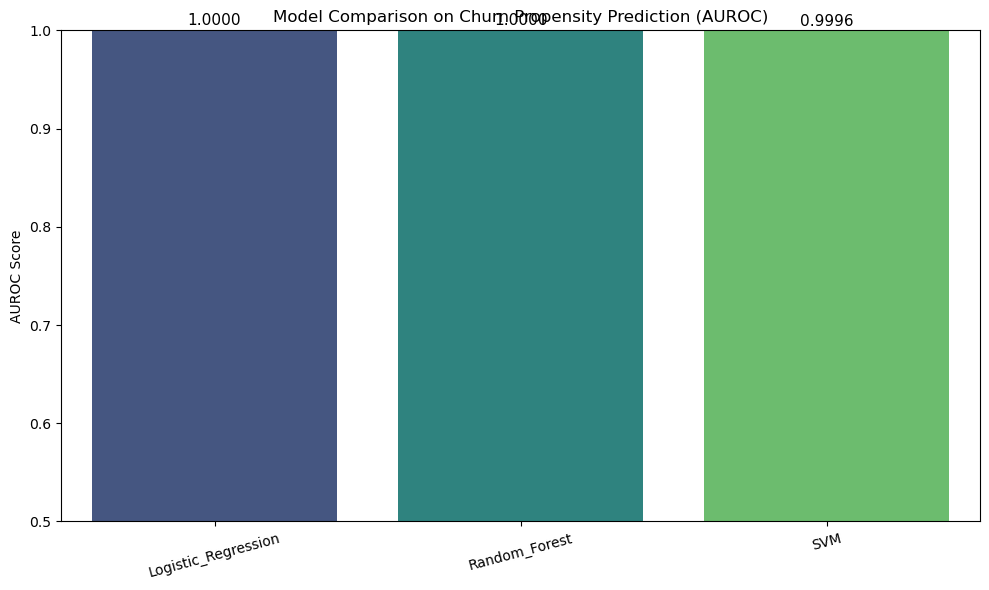

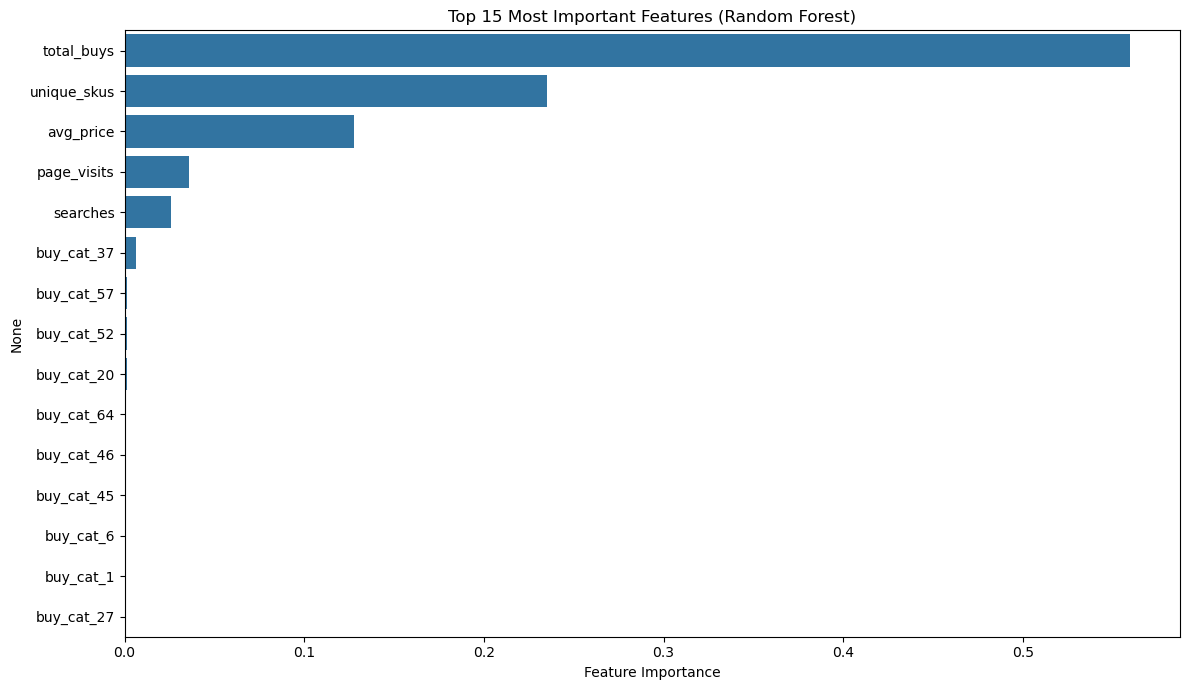


Evaluation completed. Graphs displayed above.


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

# Use small sample for fast test (~8-10 minutes)
sample_size = 8000
sample_clients = clients[:sample_size]

print(f"Building features for {sample_size} clients...")

# Merge buys with product info
buys = events["product_buy"].merge(product_props, on="sku", how="left")
buys = buys[buys["client_id"].isin(sample_clients)]

features = []
for cid in tqdm(sample_clients, desc="Processing clients"):
    row = {"client_id": cid}
    cb = buys[buys["client_id"] == cid]

    # Category purchase counts (strong signal for recommendation)
    for c in range(100):
        row[f"buy_cat_{c}"] = (cb["category"] == c).sum()

    row["total_buys"] = len(cb)
    row["unique_skus"] = cb["sku"].nunique()
    row["avg_price"] = cb["price"].mean() if not cb.empty else 0.0
    row["page_visits"] = len(events["page_visit"][events["page_visit"]["client_id"] == cid])
    row["searches"] = len(events["search_query"][events["search_query"]["client_id"] == cid])

    features.append(row)

df = pd.DataFrame(features)

# Simple target for evaluation (churn proxy: low purchase activity)
df["target"] = (df["total_buys"] <= 1).astype(int)

X = df.drop(["client_id", "target"], axis=1).fillna(0)
y = df["target"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Dataset prepared - Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Positive rate (churn proxy): {y.mean():.3f}")

# Scale features (important for Logistic Regression and SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train three models
results = {}

print("\nTraining models...")

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict_proba(X_test_scaled)[:, 1]
results["Logistic_Regression"] = roc_auc_score(y_test, lr_pred)

# 2. Random Forest
rf = RandomForestClassifier(n_estimators=120, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict_proba(X_test)[:, 1]
results["Random_Forest"] = roc_auc_score(y_test, rf_pred)

# 3. SVM (with probability)
svm = SVC(kernel='rbf', probability=True, random_state=42, max_iter=500)
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict_proba(X_test_scaled)[:, 1]
results["SVM"] = roc_auc_score(y_test, svm_pred)

# Display results
print("\nModel Performance Comparison (AUROC - higher is better)")
for model_name, score in results.items():
    print(f"{model_name:22} : {score:.4f}")

# Visualizations
plt.figure(figsize=(10, 6))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")
plt.title("Model Comparison on Churn Propensity Prediction (AUROC)")
plt.ylabel("AUROC Score")
plt.ylim(0.5, 1.0)
for i, v in enumerate(results.values()):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', fontsize=11)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

# Feature importance from Random Forest (most interpretable here)
importances = rf.feature_importances_
top_idx = np.argsort(importances)[-15:][::-1]
top_features = X.columns[top_idx]
top_importances = importances[top_idx]

plt.figure(figsize=(12, 7))
sns.barplot(x=top_importances, y=top_features)
plt.title("Top 15 Most Important Features (Random Forest)")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

print("\nEvaluation completed. Graphs displayed above.")

In [1]:
%pip install clearml

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

os.environ["CLEARML_WEB_HOST"] = "https://app.clear.ml/"
os.environ["CLEARML_API_HOST"] = "https://api.clear.ml"
os.environ["CLEARML_FILES_HOST"] = "https://files.clear.ml"

os.environ["CLEARML_API_ACCESS_KEY"] = "2H0APKE3NPXU73G7H7JWN8FE0RFQB9"
os.environ["CLEARML_API_SECRET_KEY"] = "VGIwK9zLT0SpBAL_O5DwGmCUHb1lh3OGEDdkKVQd-cxFT1JtBLx6NWr6T_KIxxgWljY"

In [3]:
from clearml import Task

task = Task.init(
    project_name="AI-Based Product Recommendation System",
    task_name="ClearML Notebook Connection Test"
)

print("ClearML connected successfully.")

ClearML Task: created new task id=2068aae40f1643029a996bbfe6540e50
2026-04-25 08:33:47,871 - clearml.Task - INFO - Storing jupyter notebook directly as code
2026-04-25 08:33:47,874 - clearml.Repository Detection - WARNING - Can't get url information for git repo in /home/sagemaker-user


2026-04-25 08:33:51.583672: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-25 08:33:51.756943: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777106031.784375    3783 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777106031.796192    3783 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-25 08:33:51.992404: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

ClearML results page: https://app.clear.ml/projects/66c109d92f0942e8a02fdaed32be3342/experiments/2068aae40f1643029a996bbfe6540e50/output/log
ClearML connected successfully.
ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start


In [4]:
from clearml import Task
from clearml.automation import PipelineController
from pathlib import Path
import subprocess

In [5]:
def data_preprocessing_step():
    from clearml import Task
    from pathlib import Path

    task = Task.current_task()
    logger = task.get_logger()

    logger.report_text("STEP 1: Data preprocessing check started.")

    dataset_path = Path("Dataset")
    input_path = dataset_path / "input"
    target_path = dataset_path / "target"
    product_props_path = dataset_path / "product_properties.parquet"
    archive_path = dataset_path / "synerise_dataset.tar.gz"

    result = {
        "dataset_folder_exists": dataset_path.exists(),
        "input_folder_exists": input_path.exists(),
        "target_folder_exists": target_path.exists(),
        "product_properties_exists": product_props_path.exists(),
        "dataset_archive_exists": archive_path.exists(),
        "dataset_path": str(dataset_path),
        "input_path": str(input_path),
        "target_path": str(target_path),
        "product_properties_path": str(product_props_path),
        "step": "Dataset structure checked"
    }

    print("STEP 1 RESULT:")
    print(result)

    logger.report_text(str(result))
    task.upload_artifact("preprocessing_summary", result)

    if not dataset_path.exists():
        raise FileNotFoundError("ERROR STEP 1: Dataset folder not found. Expected: Dataset")

    if not input_path.exists():
        raise FileNotFoundError("ERROR STEP 1: Input folder not found. Expected: Dataset/input")

    if not target_path.exists():
        raise FileNotFoundError("ERROR STEP 1: Target folder not found. Expected: Dataset/target")

    if not product_props_path.exists():
        raise FileNotFoundError("ERROR STEP 1: product_properties.parquet not found in Dataset folder")

    print("STEP 1 PASSED: Dataset structure is correct.")
    return result

In [6]:
def model_training_step():
    from clearml import Task
    import subprocess
    from pathlib import Path

    task = Task.current_task()
    logger = task.get_logger()

    logger.report_text("STEP 2: Model training and evaluation started.")

    main_file = Path("main.py")

    if not main_file.exists():
        raise FileNotFoundError("ERROR STEP 2: main.py not found in current project folder.")

    print("STEP 2: Running main.py...")

    result = subprocess.run(
        ["python", "main.py"],
        capture_output=True,
        text=True
    )

    print("===== main.py STDOUT =====")
    print(result.stdout)

    print("===== main.py STDERR / WARNINGS =====")
    print(result.stderr)

    logger.report_text("main.py stdout:")
    logger.report_text(result.stdout)

    if result.stderr:
        logger.report_text("main.py stderr / warnings:")
        logger.report_text(result.stderr)

    if result.returncode != 0:
        raise RuntimeError("ERROR STEP 2: main.py failed. Check output above.")

    print("STEP 2 PASSED: Model training and evaluation completed.")
    logger.report_text("STEP 2 PASSED: Model training and evaluation completed.")

    return "Training completed successfully"

In [7]:
def upload_results_step():
    from clearml import Task
    from pathlib import Path

    task = Task.current_task()
    logger = task.get_logger()

    logger.report_text("STEP 3: Uploading evaluation artifacts.")

    possible_files = [
        Path("metrics_comparison.csv"),
        Path("classification_reports.txt"),
        Path("results/metrics_comparison.csv"),
        Path("results/classification_reports.txt"),
    ]

    results_dir = Path("results")
    plots_dir = Path("results") / "plots"

    uploaded = []

    if results_dir.exists():
        task.upload_artifact("results_folder", results_dir)
        uploaded.append("results_folder")
        print("Uploaded: results_folder")

    if plots_dir.exists():
        task.upload_artifact("plots_folder", plots_dir)
        uploaded.append("plots_folder")
        print("Uploaded: plots_folder")

    for file_path in possible_files:
        if file_path.exists():
            task.upload_artifact(file_path.stem, file_path)
            uploaded.append(str(file_path))
            print(f"Uploaded: {file_path}")

    if not uploaded:
        print("WARNING STEP 3: No result artifacts found to upload.")
        logger.report_text("WARNING STEP 3: No result artifacts found to upload.")

    summary = {
        "uploaded_artifacts": uploaded,
        "step": "Evaluation artifact upload completed"
    }

    print("STEP 3 RESULT:")
    print(summary)

    task.upload_artifact("artifact_upload_summary", summary)
    logger.report_text(str(summary))

    return summary

In [8]:
pipe = PipelineController(
    project="AI-Based Product Recommendation System",
    name="Sprint 3 ClearML Pipeline - Debug Version",
    version="1.0"
)

pipe.set_default_execution_queue(None)

ClearML pipeline page: https://app.clear.ml/pipelines/66c109d92f0942e8a02fdaed32be3342/experiments/2068aae40f1643029a996bbfe6540e50


In [9]:
pipe.add_function_step(
    name="Step 1 - Data Preprocessing Check",
    function=data_preprocessing_step,
    function_return=["preprocessing_result"],
    cache_executed_step=False
)

Could not fetch function declared in __main__: <module '__main__'> is a built-in module
Could not fetch function imports: <module '__main__'> is a built-in module


True

In [10]:
pipe.add_function_step(
    name="Step 2 - Model Training and Evaluation",
    function=model_training_step,
    parents=["Step 1 - Data Preprocessing Check"],
    function_return=["training_result"],
    cache_executed_step=False
)

Could not fetch function declared in __main__: <module '__main__'> is a built-in module
Could not fetch function imports: <module '__main__'> is a built-in module


True

In [11]:
pipe.add_function_step(
    name="Step 3 - Upload Evaluation Artifacts",
    function=upload_results_step,
    parents=["Step 2 - Model Training and Evaluation"],
    function_return=["artifact_result"],
    cache_executed_step=False
)

Could not fetch function declared in __main__: <module '__main__'> is a built-in module
Could not fetch function imports: <module '__main__'> is a built-in module


True

In [12]:
pipe.start_locally(run_pipeline_steps_locally=True)

Launching the next 1 steps
Launching step [Step 1 - Data Preprocessing Check]
Launching step: Step 1 - Data Preprocessing Check
Parameters:
None
Configurations:
{}
Overrides:
{}


2026-04-25 08:37:53.295113: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-25 08:37:53.308571: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777106273.326244    4191 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777106273.331851    4191 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-25 08:37:53.348765: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

ClearML results page: https://app.clear.ml/projects/66c109d92f0942e8a02fdaed32be3342/experiments/380e71248a384bee83d6ced5a10117b8/output/log
STEP 1: Data preprocessing check started.
STEP 1 RESULT:
{'dataset_folder_exists': True, 'input_folder_exists': True, 'target_folder_exists': True, 'product_properties_exists': True, 'dataset_archive_exists': True, 'dataset_path': 'Dataset', 'input_path': 'Dataset/input', 'target_path': 'Dataset/target', 'product_properties_path': 'Dataset/product_properties.parquet', 'step': 'Dataset structure checked'}
{'dataset_folder_exists': True, 'input_folder_exists': True, 'target_folder_exists': True, 'product_properties_exists': True, 'dataset_archive_exists': True, 'dataset_path': 'Dataset', 'input_path': 'Dataset/input', 'target_path': 'Dataset/target', 'product_properties_path': 'Dataset/product_properties.parquet', 'step': 'Dataset structure checked'}
STEP 1 PASSED: Dataset structure is correct.
Launching the next 1 steps
Launching step [Step 2 - Mod

2026-04-25 08:38:54.876792: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-25 08:38:54.890087: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777106334.907574    4294 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777106334.913113    4294 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-25 08:38:54.929704: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

ClearML results page: https://app.clear.ml/projects/66c109d92f0942e8a02fdaed32be3342/experiments/4d7ac2623298433ea8fac693cfa8d671/output/log
STEP 2: Model training and evaluation started.
STEP 2: Running main.py...
===== main.py STDOUT =====
Loading data...
Loaded 1,000,000 clients and 1,260,365 products
Building features...
Training models...
Evaluating models...

=== MODEL PERFORMANCE COMPARISON ===
                     Accuracy  Precision  Recall  F1-Score  AUROC
Logistic Regression      0.96     0.9474     1.0     0.973    1.0
Random Forest            1.00     1.0000     1.0     1.000    1.0
Saving plots...
Plots saved to results/plots/

 Evaluation completed successfully!
Check the 'results/' folder.

===== main.py STDERR / WARNINGS =====

Building features: 100%|██████████| 100/100 [00:20<00:00,  4.78it/s]
/home/sagemaker-user/src/utils.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` 

2026-04-25 08:40:41.078573: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-25 08:40:41.091951: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777106441.109468    4432 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777106441.114984    4432 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-25 08:40:41.131705: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

ClearML results page: https://app.clear.ml/projects/66c109d92f0942e8a02fdaed32be3342/experiments/f3117c37879045c981955c960b9d664b/output/log
STEP 3: Uploading evaluation artifacts.
Uploaded: results_folder
Uploaded: plots_folder
Uploaded: results/metrics_comparison.csv
Uploaded: results/classification_reports.txt
STEP 3 RESULT:
{'uploaded_artifacts': ['results_folder', 'plots_folder', 'results/metrics_comparison.csv', 'results/classification_reports.txt'], 'step': 'Evaluation artifact upload completed'}
{'uploaded_artifacts': ['results_folder', 'plots_folder', 'results/metrics_comparison.csv', 'results/classification_reports.txt'], 'step': 'Evaluation artifact upload completed'}
Launching the next 0 steps
